In [1]:
# Connect to your Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
%cd /content/drive/MyDrive/AI Summer Intensive 2026/Day 2

/content/drive/MyDrive/Everything USF/DRAFT AI Summer Camp/Group project -- template code


In [5]:
df = pd.read_csv("data/room_occupancy.csv",parse_dates=["date"])
df.head()

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy,source_split
0,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1,training
1,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1,training
2,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1,training
3,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1,training
4,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1,training


In [6]:
print(f"Total rows: {len(df)}")

Total rows: 20560


# Exploratory Data Analysis

In [7]:
df["Occupancy"].value_counts()

,count
Occupancy,
0,15810
1,4750


In [8]:
df["Occupancy"].value_counts().max()

15810

In [9]:
baseline_accuracy = df["Occupancy"].value_counts().max()/len(df)

print(f"Always guessing that largest class would be correct {baseline_accuracy:.2%} of the time.")

Always guessing that largest class would be correct 76.90% of the time.


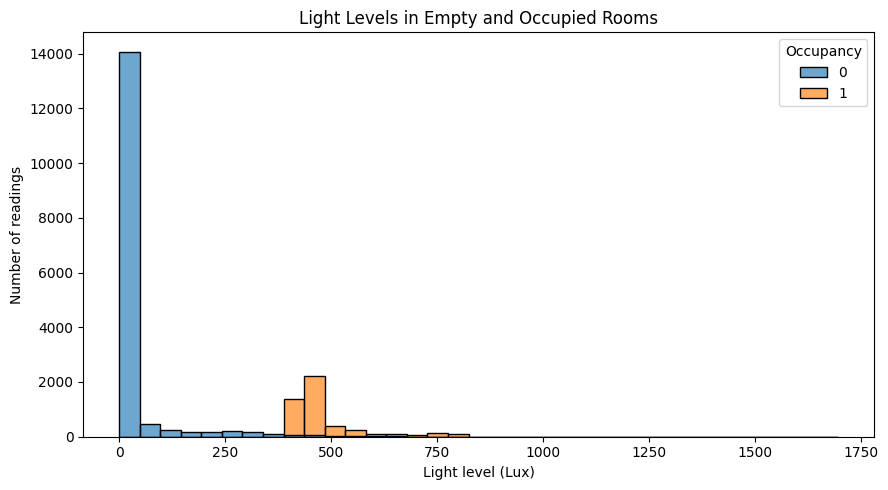

In [10]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Light",
    hue="Occupancy",
    bins=35,
    alpha=0.65,
    legend=True
)

plt.xlabel("Light level (Lux)")
plt.ylabel("Number of readings")
plt.title("Light Levels in Empty and Occupied Rooms")
plt.tight_layout()
plt.show()

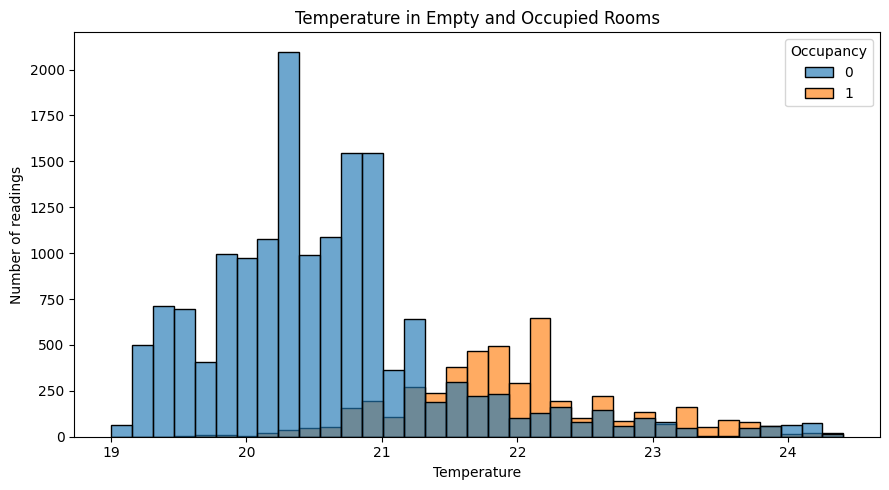

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Temperature",
    hue="Occupancy",
    bins=35,
    alpha=0.65,
    legend=True
)

plt.xlabel("Temperature")
plt.ylabel("Number of readings")
plt.title("Temperature in Empty and Occupied Rooms")
plt.tight_layout()
plt.show()

# Logistic Regression Classifier

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

## Preparing the Dataset

In [ ]:
df.head()

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy,source_split
0,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1,training
1,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1,training
2,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1,training
3,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1,training
4,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1,training


In [ ]:
train_df = df[df["source_split"] == "training"].copy()
test_df = df[df["source_split"] == "test"].copy()

print(f"Training rows: {len(train_df)}")
print(f"Testing rows:  {len(test_df)}")

Training rows: 8143
Testing rows:  12417


In [ ]:
def prepare_dataset(df, feature_list,target):
  train_df = df[df["source_split"] == "training"].copy()
  test_df = df[df["source_split"] == "test"].copy()

  X_train = train_df[feature_list]
  y_train = train_df[target]

  X_test = test_df[feature_list]
  y_test = test_df[target]

  return X_train, X_test, y_train, y_test

In [ ]:
features_list = ['Light']
target = 'Occupancy'
X_train, X_test, y_train, y_test = prepare_dataset(df, features_list, target)
print(f"Total training data points: {len(X_train)}")
print(f"Total testing data points: {len(X_test)}")

Total training data points: 8143
Total testing data points: 12417


## Fitting the Model to the Training Data

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
def train_model(X_train, y_train):
  model = LogisticRegression()
  model.fit(X_train, y_train)
  return model

In [ ]:
model = train_model(X_train, y_train)

## Evaluating the Fitted Model using Test Data

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test,y_pred)

print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 98.94%


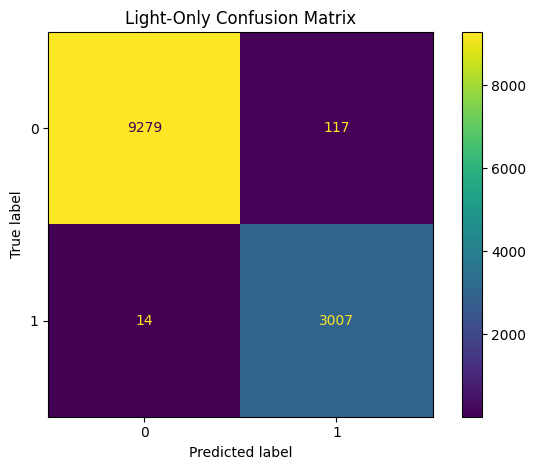

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

plt.title("Light-Only Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
def evaluate_model(model, X_test, y_test):
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  print(f"Test accuracy: {accuracy:.2%}")
  ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
  plt.title("Light-Only Confusion Matrix")
  plt.tight_layout()
  plt.show()
  return y_pred

Test accuracy: 98.94%


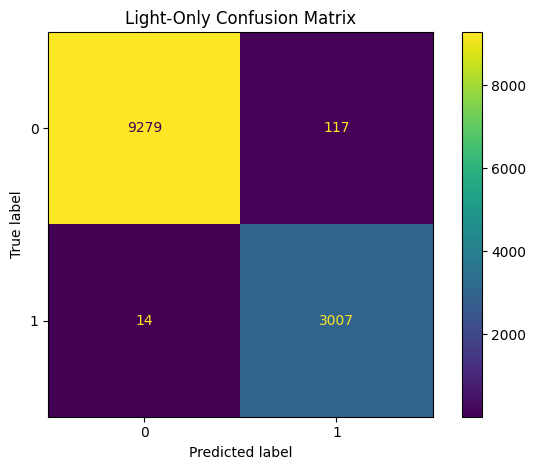

In [ ]:
y_pred = evaluate_model(model, X_test, y_test)